In [241]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.inspection import permutation_importance

from sklearn.inspection import permutation_importance

In [13]:
dfpisa = pd.read_csv("dfCOG.csv")
dfpisa=dfpisa.drop(['Unnamed: 0'], axis = 1)
dfpisa.describe()
dfpisa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Columns: 128 entries, CNTRYID to high_love_learn_cat
dtypes: float64(83), int64(31), object(14)
memory usage: 81.1+ KB


In [15]:
print(dfpisa.isnull().sum())

CNTRYID                0
country                0
math_all_mean          0
math_10th_mean         0
math_25th_mean         0
                      ..
high_grit_cat          9
low_grit               9
low_grit_cat           9
high_love_learn        5
high_love_learn_cat    5
Length: 128, dtype: int64


In [123]:
#Exercise Questions, lots of missing data
# "WB32Q01NA_8.0_proportion", 
#        "WB32Q01NA_1.0_proportion", "WB32Q01NA_2.0_proportion", "WB32Q01NA_3.0_proportion", 
#        "WB32Q01NA_4.0_proportion", "WB32Q01NA_5.0_proportion", "WB32Q01NA_6.0_proportion", 
#        "WB32Q01NA_7.0_proportion", "WB32Q02NA_1.0_proportion", "WB32Q02NA_2.0_proportion", 
#        "WB32Q02NA_3.0_proportion", "WB32Q02NA_4.0_proportion", "WB32Q02NA_5.0_proportion", 
#        "WB32Q02NA_6.0_proportion", "WB32Q02NA_7.0_proportion", "WB32Q02NA_8.0_proportion",
binom_data = dfpisa.filter(["ST258Q01JA_1.0_proportion", "ST258Q01JA_2.0_proportion", "ST258Q01JA_3.0_proportion",
        "ST258Q01JA_4.0_proportion", "ST258Q01JA_5.0_proportion", "Geo_Region", "ed_percent_gdp", 
        "ses_all_mean", "math_min_proficiency"]).copy()
binom_data.dropna(inplace=True)


In [129]:
binom_data[["ses_all_mean", "ed_percent_gdp"]].describe()

,ses_all_mean,ed_percent_gdp
count,66.000000,66.000000
mean,-0.439242,4.389062
std,0.594977,1.128043
min,-2.010000,1.275171
25%,-0.827500,3.593097
50%,-0.345000,4.615470
75%,0.042500,5.201258
max,0.480000,7.139665


In [131]:
X = binom_data.drop(columns=["math_min_proficiency"])
y = binom_data["math_min_proficiency"].copy()
X = pd.get_dummies(X, columns=["Geo_Region"])


In [143]:
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns, index=X.index)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.20, stratify=y, random_state=123)


X.info()
y.info()
print(X_train.shape)
print(y_train.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 66 entries, 0 to 80
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ST258Q01JA_1.0_proportion  66 non-null     float64
 1   ST258Q01JA_2.0_proportion  66 non-null     float64
 2   ST258Q01JA_3.0_proportion  66 non-null     float64
 3   ST258Q01JA_4.0_proportion  66 non-null     float64
 4   ST258Q01JA_5.0_proportion  66 non-null     float64
 5   ed_percent_gdp             66 non-null     float64
 6   ses_all_mean               66 non-null     float64
 7   Geo_Region_Asia            66 non-null     bool   
 8   Geo_Region_Eastern Europe  66 non-null     bool   
 9   Geo_Region_Middle East     66 non-null     bool   
 10  Geo_Region_North America   66 non-null     bool   
 11  Geo_Region_South America   66 non-null     bool   
 12  Geo_Region_Western Europe  66 non-null     bool   
dtypes: bool(6), float64(7)
memory usage: 4.5 KB
<class 'panda

In [147]:
X_scaled[["ses_all_mean", "ed_percent_gdp"]].describe()

,ses_all_mean,ed_percent_gdp
count,6.600000e+01,6.600000e+01
mean,1.328903e-16,-2.052230e-16
std,1.007663e+00,1.007663e+00
min,-2.660260e+00,-2.781590e+00
25%,-6.575593e-01,-7.110229e-01
50%,1.596105e-01,2.022470e-01
75%,8.158867e-01,7.255220e-01
max,1.556844e+00,2.457071e+00


In [149]:
bayes = GaussianNB()

param_grid = {"var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4]}

In [151]:
grid = GridSearchCV(estimator = bayes, param_grid = param_grid, cv=5, scoring = "f1")
grid.fit(X_train, y_train)

C:\Users\themo\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\themo\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\themo\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 234, in __call__
    return self._score(
           ^^^^^^^^^^^^
  File "C:\Users\themo\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 282, in _score
    return self._sign * self._score_func(y_true, y_pred, **self._kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\themo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py", line 1146, in f1_score
    return fbeta_score(
           ^^^^^^^^^^^

GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06, 1e-05,
                                           0.0001]},
             scoring='f1')

In [153]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

y_pred = grid.best_estimator_.predict(X_test)

print(classification_report(y_test, y_pred))

Best Parameters: {'var_smoothing': 1e-09}
Best CV Score: nan
                           precision    recall  f1-score   support

Below minimum proficiency       0.71      0.83      0.77         6
  Met minimum proficiency       0.86      0.75      0.80         8

                 accuracy                           0.79        14
                macro avg       0.79      0.79      0.78        14
             weighted avg       0.80      0.79      0.79        14



In [155]:
test_accuracy_bayes = accuracy_score(y_test, y_pred)
print("Test accuracy rate is", test_accuracy_bayes)

Test accuracy rate is 0.7857142857142857


In [157]:
print(confusion_matrix(y_test, y_pred))
print("")
print(y_test.value_counts())

[[5 1]
 [2 6]]

math_min_proficiency
Met minimum proficiency      8
Below minimum proficiency    6
Name: count, dtype: int64


In [187]:
svm = SVC(probability = True)

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.001, 0.0001],
    'kernel': ['rbf', 'linear', 'poly']
}

In [189]:
grid_svm = GridSearchCV(estimator=svm, param_grid=param_grid_svm, cv=5, scoring='f1')
grid_svm.fit(X_train, y_train)

C:\Users\themo\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\themo\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\themo\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 234, in __call__
    return self._score(
           ^^^^^^^^^^^^
  File "C:\Users\themo\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 282, in _score
    return self._sign * self._score_func(y_true, y_pred, **self._kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\themo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py", line 1146, in f1_score
    return fbeta_score(
           ^^^^^^^^^^^

GridSearchCV(cv=5, estimator=SVC(probability=True),
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 0.01, 0.001, 0.0001],
                         'kernel': ['rbf', 'linear', 'poly']},
             scoring='f1')

In [193]:
print("Best Parameters:", grid_svm.best_params_)
print("Best CV Score:", grid_svm.best_score_)

y_pred_svm = grid_svm.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_svm))

Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score: nan
                           precision    recall  f1-score   support

Below minimum proficiency       0.00      0.00      0.00         6
  Met minimum proficiency       0.57      1.00      0.73         8

                 accuracy                           0.57        14
                macro avg       0.29      0.50      0.36        14
             weighted avg       0.33      0.57      0.42        14



C:\Users\themo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\themo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\themo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [195]:
test_accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("Test accuracy rate is", test_accuracy_svm)

Test accuracy rate is 0.5714285714285714


In [197]:
print(confusion_matrix(y_test, y_pred_svm))
print("")
print(y_test.value_counts())

[[0 6]
 [0 8]]

math_min_proficiency
Met minimum proficiency      8
Below minimum proficiency    6
Name: count, dtype: int64


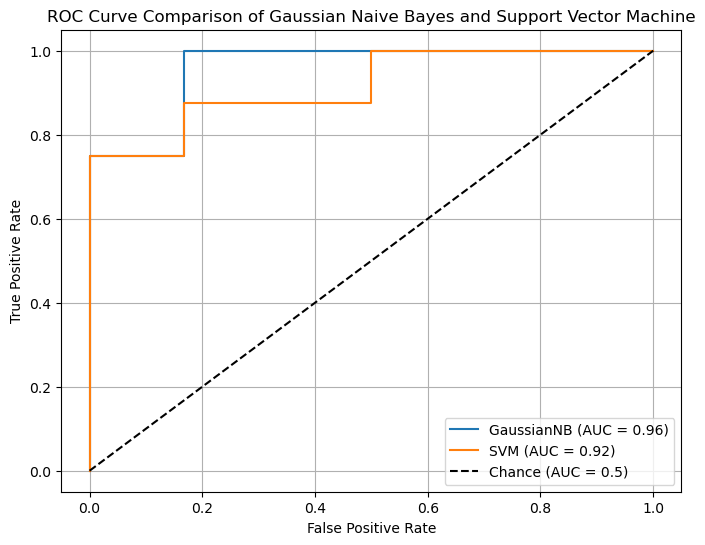

In [169]:
y_score_gnb = grid.best_estimator_.predict_proba(X_test)[:, 1]
y_score_svm = grid_svm.best_estimator_.predict_proba(X_test)[:, 1]


fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_score_gnb, pos_label = 'Met minimum proficiency')
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm, pos_label = 'Met minimum proficiency')

auc_gnb = auc(fpr_gnb, tpr_gnb)
auc_svm = auc(fpr_svm, tpr_svm)


plt.figure(figsize=(8, 6))
plt.plot(fpr_gnb, tpr_gnb, label=f"GaussianNB (AUC = {auc_gnb:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Chance (AUC = 0.5)")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of Gaussian Naive Bayes and Support Vector Machine')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [229]:
def create_model_df(y_true, y_pred, model_name):
    # Generate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Convert to DataFrame
    df_cm = pd.DataFrame(cm, columns=['Predicted: < min prof', 'Predicted: min prof'])

    df_cm['row_num'] = range(1, len(df_cm) + 1)

    # Generate classification report as a dictionary
    cl_dict = classification_report(y_true, y_pred, output_dict=True)

    # Convert to DataFrame and transpose
    df_cl = pd.DataFrame(cl_dict).T

    df_cl['Model'] = model_name
    df_cl['row_num'] = range(1, len(df_cl) + 1)

    del df_cl['support']

    df_cmcl = pd.merge(df_cm, df_cl, how='left', on = 'row_num')

    return (df_cmcl)

In [231]:
df_bayes = create_model_df(y_test, y_pred, "Gaussian NB")
df_svm = create_model_df(y_test, y_pred_svm, "SVM")


compare_df = pd.concat([df_bayes, df_svm], ignore_index=True, axis=0)

# Add column with the actual values
col         = 'row_num'
conditions  = [ compare_df[col] == 1, compare_df[col] == 2]
choices     = [ '< min prof', 'min prof']
default_value = " "

compare_df["Actual"] = np.select(conditions, choices, default=default_value)

# Delete row number
del compare_df['row_num']

# reorder columns
compare_df = compare_df[['Model', 'Actual', 'Predicted: < min prof', 'Predicted: min prof', 'precision', 'recall', 'f1-score']]

C:\Users\themo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\themo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\themo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [233]:
pd.set_option('display.expand_frame_repr', False)
print(compare_df)

         Model      Actual  Predicted: < min prof  Predicted: min prof  precision    recall  f1-score
0  Gaussian NB  < min prof                      5                    1   0.714286  0.833333  0.769231
1  Gaussian NB    min prof                      2                    6   0.857143  0.750000  0.800000
2          SVM  < min prof                      0                    6   0.000000  0.000000  0.000000
3          SVM    min prof                      0                    8   0.571429  1.000000  0.727273


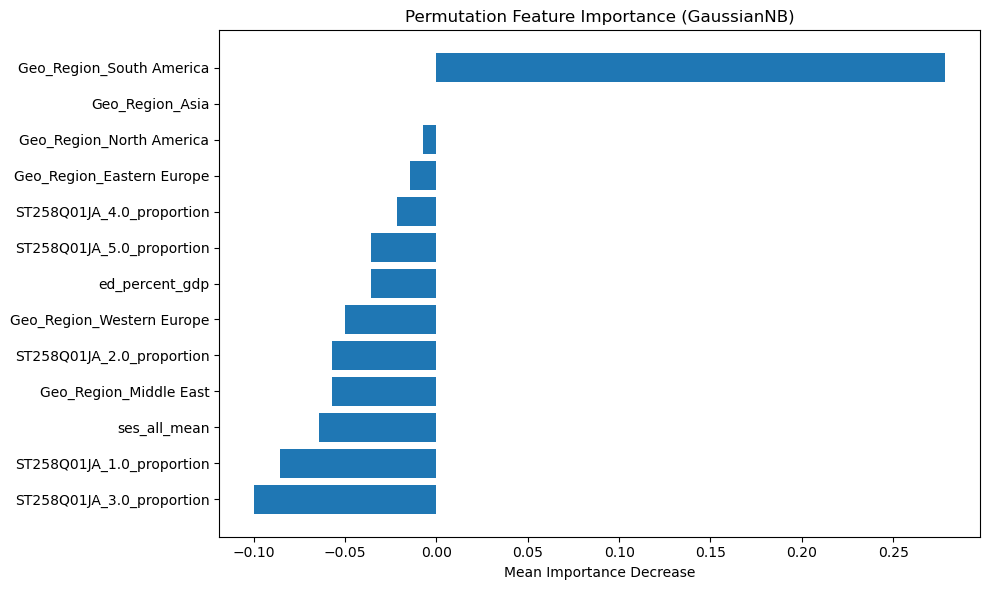

In [247]:
result = permutation_importance(grid.best_estimator_, X_test, y_test, n_repeats=10, random_state=123)

importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance (GaussianNB)")
plt.xlabel("Mean Importance Decrease")
plt.tight_layout()
plt.show()

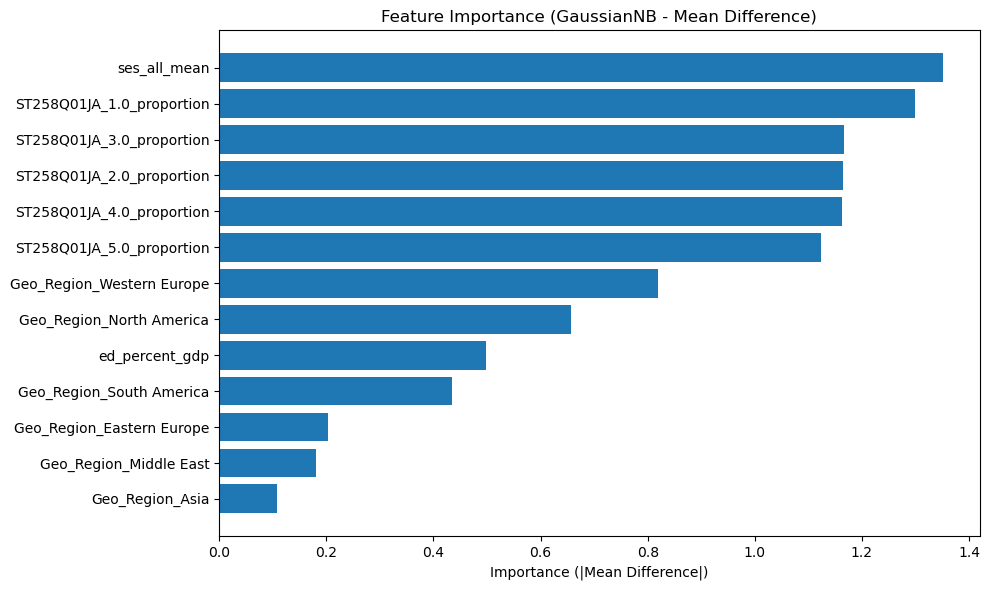

In [251]:
nb = grid.best_estimator_

means = nb.theta_    # shape: (n_classes, n_features)
vars_ = nb.var_    # shape: (n_classes, n_features)

# Calculate importance as abs(mean difference between classes)
importance = np.abs(means[0] - means[1])


feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'Feature {i}' for i in range(X_train.shape[1])]
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (GaussianNB - Mean Difference)")
plt.xlabel("Importance (|Mean Difference|)")
plt.tight_layout()
plt.show()
